# Grover's search - Part 3 
**Quantum Resource Estimation** 

In the previous tutorial we wrote a number of Qubricks that implemented Grover's search algorithm applied to SAT problems in Construct. Specifically these Qubricks were _nested_: our top level `GroversSearchSATProblem` called `EvaluateFormula`, which called `EvaluateClause`. This is a common structure in quantum algorithms; defining reusable sequences of gates and building your quantum algorithm in a modular fashion. Qubricks are indispensable in describing large scale quantum algorithms efficiently, without overloading the user in detail. 

Below we reproduce our Qubricks, and introduce several new ones. Previously the gates in these new Qubricks were just called by `GroversSearchSATProblem`, but, as we will see, it can be helpful to define Qubricks for the sole purpose of 'bucketing' snippets of our circuit. Here is a brief breakdown of the new Qubricks:

- `PhaseKickbackPrep`: Prepares the phase kickback auxiliary qubit. This is invariant across problem instances.
- `MeanStatePrep`: Prepares our input register in the mean state. Grows with input register size.
- `ReflectionAboutTheMean`: Bundles together `MeanStatePrep` and reflection about zero to perform reflection about the mean state.

In [ ]:
from psiqdk.workbench import Qubrick, Qubits, QPU


class EvaluateClause(Qubrick):
    "Qubrick that evaluates one SAT clause"

    def _compute(self, x: Qubits, y: Qubits, literals: list[tuple[int, bool]]) -> None:
        # Build a mask of control qubits for this clause
        ind, pos = literals[0]
        controls = x[ind] if pos else ~x[ind]
        for ind, pos in literals[1:]:
            controls |= x[ind] if pos else ~x[ind]

        # Calculate OR of the literals in the clause
        y.x(cond=~controls)
        y.x()


class EvaluateFormula(Qubrick):
    "Qubrick that evaluates a SAT formula"

    def _compute(
        self, x: Qubits, y: Qubits, clauses: list[list[tuple[int, bool]]]
    ) -> None:
        num_clauses = len(clauses)
        # Allocate auxiliary qubits for clause evaluation
        a = self.alloc_temp_qreg(num_clauses, "a", release_after_compute=True)

        clause_evaluator = EvaluateClause()

        # Evaluate clauses and store results in corresponding auxiliary qubits
        for ind, clause in enumerate(clauses):
            clause_evaluator.compute(x, a[ind], clause)

        # Evaluate the formula as the AND of auxiliary qubits
        y.x(cond=a)

        # Uncompute clauses evaluation
        for _ in range(num_clauses):
            clause_evaluator.uncompute()


class PhaseKickbackPrep(Qubrick):
    """Qubrick to prepare an auxiliary qubit in |->."""

    def _compute(self, register: Qubits):
        register.x()
        register.had()


class MeanStatePrep(Qubrick):
    """Qubrick to prepare the mean state on our input register."""

    def _compute(self, register: Qubits):
        register.had()


class ReflectionAboutTheMean(Qubrick):
    """Qubrick to perform reflection about the mean."""

    def _compute(self, register: Qubits, mean_state_preparation_qbk: MeanStatePrep):
        mean_state_preparation_qbk.compute(register, dagger=True)
        (~register).reflect()
        mean_state_preparation_qbk.compute(register)


class GroversSearchSATProblem(Qubrick):
    """Qubrick to solve the SAT problem for the given formula using the given iteration count."""

    def _compute(
        self,
        num_inputs: int,
        clauses: list[list[tuple[int, bool]]],
        num_iterations: int,
    ) -> None:

        x = self.alloc_temp_qreg(num_inputs, "x")
        minus = self.alloc_temp_qreg(1, "|-⟩")

        oracle = EvaluateFormula()
        reflection_about_the_mean = ReflectionAboutTheMean()
        mean_state_preparation = MeanStatePrep()

        mean_state_preparation.compute(x)
        PhaseKickbackPrep().compute(minus)

        for _ in range(num_iterations):
            # Oracle call
            oracle.compute(x, minus, clauses)
            # Reflection about the mean
            reflection_about_the_mean.compute(x, mean_state_preparation)

        # Measure
        res = x.read()
        self.set_classical_result(res, "result")

As we saw previously, for any Workbench QPU object you can use the `resource_estimator` interface to get an overview of the required logical resources.

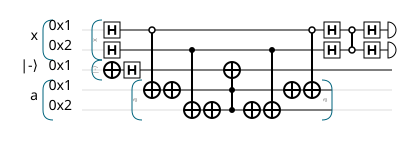

{'active_volume': 88,
 'gidney_lelbows': 0,
 'gidney_relbows': 0,
 'measurements': 2,
 'rotations': 0,
 'pprs': 0,
 'ppms': 0,
 't_gates': 0,
 'toffs': 1,
 'qubit_highwater': 5}

In [2]:
num_inputs = 2
# Clause: (x₀) ∧ (¬x₁)
clauses = [[(0, True)], [(1, False)]]

qpu = QPU(num_qubits=num_inputs + len(clauses) + 1)
grovers_search = GroversSearchSATProblem(qc=qpu)
success = False
correct = 1

while not success:
    grovers_search.compute(num_inputs, clauses, 1)
    success = grovers_search.get_classical_result() == correct
qpu.draw()

from psiqdk.workbench.qre import resource_estimator
resource_estimator(qpu).resources()

Recall that our formula was chosen to ensure a 100\% success rate; if we instead opted for the formula introduced in the first Grover solver tutorial, $\left(x_0 \lor x_1\right) \land \left(x_0 \lor \neg x_2\right)$, the circuit would be repeated until it produced a correct answer, increasing its resource requirements. 

In general, there can be multiple ways to solve a problem using Grover's search. We can modify the number of iterations, trading off the cost of a single algorithm run for the success probability. We can also change the encoding of the search problem and thus the implementation of the quantum oracle. Alternatively, we can use different routines to prepare the mean state.

The number of degrees of freedom in this circuit makes parameterizing resource estimation tricky, as each execution can have different resource requirements even with the same settings. Instead, we will analyze the above circuit and attempt to identify _bottlenecks_: Qubricks that, perhaps unexpectedly, demand more resources than others. Often it is unavoidable that a particular Qubrick requires more resources than others, but this kind of analysis allows us to focus optimization efforts onto particularly expensive subcircuits. By highlighting where our logical resource budget is being spent, we may be able to improve our algorithms further.


## 1. Visualizing QREs with Resource Analyzer

Workbench QPUs contain a lot of information, even for small circuits! While the `resource_estimator` interface can capture all the information about QREs, sometimes it is best to analyze it visually rather than programmatically.

PsiQuantum's Resource Analyzer offers another avenue for algorithm analysis: designed specifically to visualize the information contained in these kinds of `QPU` objects, and to help better understand how total metric values are created from lower level gate instructions. 

Programs contained in Workbench QPUs can be serialized directly into a format that can then be digested into Resource Analyzer:

In [3]:
from construct_tools import CallGraph
from psiqdk.workbench.integrations import resource_analyzer

data = resource_analyzer.export(qpu)
CallGraph(data)

CallGraph()

<img src="./media/satsolver_resource_counts.svg"/>

The callgraphs obtained from Resource Analyzer are interactive, and the boxes are labelled with either the gate name (`read` in the example above) or the Qubrick label. Each box will show how often it was called, as well as its contribution to a specific metric.

You can read the full documentation on Resource Analyzer [here](https://open-docs.construct.psiquantum.com/resource-analyzer/index.html).

## 2. bartiq and QREF

The Workbench `resource_estimator` interface has not been designed with analysis of resource hierarchy in mind. A tool which allows for an easier exploration of this aspect is [bartiq](https://github.com/PsiQ/bartiq), our open source quantum resource estimation software package.

In order to interface between a Workbench QPU object and bartiq, we can employ our bespoke data format for quantum resource estimation: the [Quantum Resource Estimation Format (QREF)](https://github.com/PsiQ/QREF). 

This format is also open source, and is built on top of JSON schema. As an analogue to how quantum algorithms can be described as nested Qubricks, bartiq and QREF employ the language of 'routines' and 'subroutines'. For our purposes, routines and Qubricks can be viewed equivalently.

Workbench QPU objects can be serialized directly to QREF:

In [4]:
qpu_qref = qpu.to_serializable(dialect="qref")

# This prints a lot of information, uncomment and run at your own risk!
# qpu_qref

The QREF representation of a Workbench QPU contains a lot of information: it's a full description of our implemented algorithm as a nested dictionary including qubit register sizes, input and output connections and all Qubricks called within other Qubricks. We chose to not print the raw data here for brevity, but it is helpful to gain insight into the structure of the QREF object. The top level contains only two entries: `version` and `program`. The `version` entry tells us which QREF version is being run, and `program` contains our algorithm! Inspecting the dictionary keys of the `program` entry:

In [5]:
qpu_qref["program"].keys()

dict_keys(['name', 'type', 'children', 'connections', 'resources', 'ports', 'input_params', 'linked_params'])

* **name**:
    - The name of the Qubrick (or `Routine`). The topmost level of the `program` is always called `root`.
* **type**:
    - The type of the Qubrick. Similarly, the topmost level is always defined as type `root`.
* **children**:
    - Any Qubricks called. At the top level of `program`, this is all Qubricks that are called _directly_ on the QPU. In our case, this is only `GroverSATSearchProblem`.
* **connections** and **ports**:
    - `ports` is the language QREF and bartiq use for qubit registers. `connections` defines how these ports connect across the immediate children.
* **resources**:
    - Any resources required by this level of the routine, similar to what `resource_estimator` prints.
* **input_params** and **linked_params**:
    - `input_params` lists any local variables that this level needs; `linked_params` lists any variables this levels _children_ needs.
    
To see how these fields relate back to our implemented algorithm, we can take a closer look at the `child` of the `root`: `GroverSearchSATProblem_compute_0`.

In [6]:
grover_routine = qpu_qref["program"]["children"][0]
grover_routine["name"]

'GroversSearchSATProblem_compute_0'

If we printed this object directly, it would be as challenging to parse as `qpu_qref` - QREF is recursive, so this object still contains our entire algorithm! If we ignore the `children` field however, we can see a snapshot of the information that QREF tracks:

In [7]:
grover_routine_no_children = {
    key: val for key, val in grover_routine.items() if key != "children"
}
grover_routine_no_children

{'name': 'GroversSearchSATProblem_compute_0',
 'type': 'qubrick',
 'connections': ['qubits_alloc_0.out_0 -> MeanStatePrep_compute_0.in_0',
  'qubits_alloc_1.out_0 -> PhaseKickbackPrep_compute_0.in_0',
  'MeanStatePrep_compute_0.out_0 -> EvaluateFormula_compute_0.in_0',
  'PhaseKickbackPrep_compute_0.out_0 -> EvaluateFormula_compute_0.in_1',
  'EvaluateFormula_compute_0.out_0 -> ReflectionAboutTheMean_compute_0.in_0',
  'ReflectionAboutTheMean_compute_0.out_0 -> read_0.thru_0',
  'read_0.thru_0 -> out_0',
  'EvaluateFormula_compute_0.out_1 -> out_1'],
 'resources': [],
 'ports': [{'name': 'out_0', 'size': None, 'direction': 'output'},
  {'name': 'out_1', 'size': None, 'direction': 'output'}],
 'input_params': [],
 'linked_params': []}

The first two fields are self-explanatory: the `name` and `type` of the `routine` are inherited from Workbench.

As mentioned, the `connections` field should be viewed as the qubit wiring in our circuit. The first entry in `connections` is: 
```
qubits_alloc_0.out_0 -> MeanStatePrep_compute_0.in_0
```
_Qubit allocation_ is itself a `routine`: by design QREF does not have the ability to distinguish between qubit operations and gate operations as this information is not relevant for resource estimation. This entry in `connections` tells us that the first output (`_out_0`) of qubit allocation should be considered as the first input (`_in_0`) to `MeanStatePrep`. Looking at our `GroversSearchSATProblem` code above, this is exactly how we constructed our circuit. A QREF object extracts and summarizes this information, and can help identify unintended wiring between subcircuits. 

The `ports` entry contains a list, itself with two entries: the `GroverSATSearchProblem` Qubrick requires two qubit registers. The fields `input_params` and `linked_params` are empty, as we have no local or child variables in this algorithm.

<div class="alert alert-block alert-info">
<b>Note:</b> You could reasonably ask why the <code>clauses</code> or <code>num_iterations</code> do not count as <code>input_params</code> to our algorithm. This is a subtle difference between <i>numeric</i> routines and <i>symbolic</i> routines. We fixed values for <code>clauses</code> and <code>num_iterations</code> when we called the <code>compute</code> method of the <code>Qubrick</code>; they are no longer 'parameters' but constants.

Symbolic routines (equivalently, Workbench `SymbolicQPU` programs) can output unevaluated resource estimates. 
</div>


Some information is noticeably absent, namely the `resources` and `size` of the `ports`. In the language of bartiq, this QREF object corresponds to an _uncompiled_ `routine`: the overall resources and qubit register sizes is information contained in the lower levels of the hierarchy. In order to propagate that information up to `root`, we must _compile_.

First let's load `qpu_qref` into bartiq as a `Routine` object.

In [8]:
from bartiq import Routine, sympy_backend

routine = Routine.from_qref(qpu_qref, sympy_backend)

bartiq is built to handle multiple `backends` in order to parse any symbolic expressions that may be present in the routine. Here we're using [SymPy](https://www.sympy.org/en/index.html) backend, a Python library for symbolic mathematics. While we don't have any symbolic expressions in our routine, we still need to supply a backend! At present, `sympy_backend` is the only backend implemented in bartiq. 

The `Routine` dataclass is a useful handler for QREF dictionaries, turning keys into callable attributes, but it contains no new information compared to `qpu_qref` above. We now want to compile the routine!

In [9]:
from bartiq import CompiledRoutine
from bartiq.compilation import compile_routine, CompilationFlags

compiled_grover: CompiledRoutine = compile_routine(
    routine=routine, compilation_flags=CompilationFlags.EXPAND_RESOURCES
).routine

The `compile_routine` function returns a `CompilationResult` dataclass; we only care about the `CompiledRoutine` object from the result, not any metadata.

We added in a `compilation_flag`: `EXPAND_RESOURCES`. By default, bartiq compiles resources in a transitive fashion for performance reasons. This flag ensures we get full expressions at every level of the compiled routine.

From a compiled routine we can inspect the `resource_values` property, which will show us similar attributes to those obtained through `resource_estimator` interface:

In [10]:
compiled_grover.resource_values

{'active_volume': 88,
 'gidney_lelbows': 0,
 'gidney_relbows': 0,
 'measurements': 2,
 'rotations': 0,
 't_gates': 0,
 'toffs': 1}

In [11]:
resource_estimator(qpu).resources()

{'active_volume': 88,
 'gidney_lelbows': 0,
 'gidney_relbows': 0,
 'measurements': 2,
 'rotations': 0,
 'pprs': 0,
 'ppms': 0,
 't_gates': 0,
 'toffs': 1,
 'qubit_highwater': 5}

We don't see `qubit_highwater` in the bartiq resources because it is a property derived from the `port` sizes in the routine, and must be calculated separately. This is possible in bartiq with a few extra steps:

In [12]:
from bartiq.compilation.derived_resources import calculate_highwater

compiled_grover_with_qubit_highwater: CompiledRoutine = compile_routine(
    routine=routine,
    compilation_flags=CompilationFlags.EXPAND_RESOURCES,
    derived_resources=[
        {
            "name": "qubit_highwater",
            "type": "additive",
            "calculate": calculate_highwater,
        }
    ],
).routine
compiled_grover_with_qubit_highwater.resource_values

{'qubit_highwater': 5,
 'active_volume': 88,
 'gidney_lelbows': 0,
 'gidney_relbows': 0,
 'measurements': 2,
 'rotations': 0,
 't_gates': 0,
 'toffs': 1}

## 3. Finding the bottleneck

At this stage it might appear that we have gone through many more steps to get to the same functionality that is natively available in Workbench. While Workbench provides a high level overview in a single method call, bartiq give us a much more fine-grained perspective on resources and which routine or subroutine is contributing towards them. Because of the recursive nature of QREF, we're able to easily get a resource dictionary for child routines.

As mentioned, the top level of a routine is always `root`. So to access our `GroversSearchSATProblem`, we have to step into the child routine:

In [13]:
compiled_grover_with_qubit_highwater = compiled_grover_with_qubit_highwater.children[
    "GroversSearchSATProblem_compute_0"
]

Now, we can investigate its children:

In [14]:
list(compiled_grover_with_qubit_highwater.children.keys())

['qubits_alloc_0',
 'qubits_alloc_1',
 'MeanStatePrep_compute_0',
 'PhaseKickbackPrep_compute_0',
 'EvaluateFormula_compute_0',
 'ReflectionAboutTheMean_compute_0',
 'read_0']

In addition to our manually defined Qubricks, we also have qubit allocation (`qubit_alloc_0/1`) and measurement (`read_0`).  

Below we step into the `MeanStatePrep` routine and inspect its resource contributions:

In [15]:
compiled_grover_with_qubit_highwater.children["MeanStatePrep_compute_0"].resource_values

{'active_volume': 6,
 'gidney_lelbows': 0,
 'gidney_relbows': 0,
 'measurements': 0,
 'rotations': 0,
 't_gates': 0,
 'toffs': 0,
 'qubit_highwater': 2}

Actually, we can easily write a short script to investigate the resource cost of each child routine. We will focus on the active volume resource.

In [16]:
def print_child_contributions_to_resource(
    routine: CompiledRoutine, resource: str = "active_volume"
):
    """For a given routine, check the resource cost of its children."""
    for child_name, child_routine in routine.children.items():
        if resource in child_routine.resource_values:
            print(
                f"{child_name} - {resource}: {child_routine.resource_values[resource]}"
            )


print_child_contributions_to_resource(compiled_grover_with_qubit_highwater)

MeanStatePrep_compute_0 - active_volume: 6
PhaseKickbackPrep_compute_0 - active_volume: 3
EvaluateFormula_compute_0 - active_volume: 63
ReflectionAboutTheMean_compute_0 - active_volume: 16
read_0 - active_volume: 0.0


In [17]:
print_child_contributions_to_resource(
    compiled_grover_with_qubit_highwater.children["MeanStatePrep_compute_0"]
)

had_0 - active_volume: 6.0


In [18]:
qpu_qref["program"]["children"][0]["children"][2]["children"][0]["resources"]

[{'name': 'toffs', 'type': 'additive', 'value': 0},
 {'name': 't_gates', 'type': 'additive', 'value': 0},
 {'name': 'measurements', 'type': 'additive', 'value': 0},
 {'name': 'rotations', 'type': 'additive', 'value': 0},
 {'name': 'gidney_lelbows', 'type': 'additive', 'value': 0},
 {'name': 'gidney_relbows', 'type': 'additive', 'value': 0},
 {'name': 'active_volume', 'type': 'additive', 'value': 6.0},
 {'name': 'local_ancillae', 'type': 'qubits', 'value': 0}]

We see that, where the overall routine requires an active volume (AV) of 88, `EvaluateFormula` requires an AV of 63 and contributes the bulk of our requirement. We can go further down the hierarchy still:

In [19]:
print_child_contributions_to_resource(
    compiled_grover_with_qubit_highwater.children["EvaluateFormula_compute_0"]
)

EvaluateClause_compute_0 - active_volume: 4
EvaluateClause_compute_1 - active_volume: 4
x_0 - active_volume: 47.0
EvaluateClause_uncompute_0 - active_volume: 4
EvaluateClause_uncompute_1 - active_volume: 4


<div class="alert alert-block alert-info">
<b>Note:</b>  <code>EvaluateFormula_compute_0</code> has five subroutines that contribute towards AV: <code>EvaluateClause_compute_0</code>, <code>EvaluateClause_compute_1</code>, <code>EvaluateClause_uncompute_0</code>, <code>EvaluateClause_uncompute_1</code>, and <code>x_0</code>. Because we have two clauses, we have two <code>EvaluateClause</code> compute/uncompute pairs. If we had introduced more clauses, our number of routines at this level would have increased commensurately.
</div>

We can see that each `EvaluateClause` call only requires an AV of 4, but `x_0` requires an AV of 47! We can then investigate this routine:

In [20]:
x_routine = compiled_grover_with_qubit_highwater.children[
    "EvaluateFormula_compute_0"
].children["x_0"]
x_routine.children

{}

This routine has no children - meaning it is a primitive operation. With some thought, we can deduce that this routine corresponds to this line in our Qubrick:
```python
    # Evaluate the formula as the AND of auxiliary qubits
    y.x(cond=a)
```
Because this `X` gate is being conditioned on a register of size greater than 1, it is much more difficult to implement. In our case this is a Toffoli gate. Out of a total required AV of 88, more than half comes from this single Toffoli operation.

However, bear in mind that for a formula with more complicated clauses (such as those that use more than one qubit each), evaluating the clauses would have been more expensive than aggregating their results into the formula. This is part of the reason why resource estimation, and by extension bottleneck analysis, is so important. The most resource intensive operation (with regard to AV) in this circuit may not necessarily be the most resource intensive operation in another implementation of this algorithm - or even the same implementation on another problem instance!

## Conclusion

Here we introduced bartiq and QREF, and how these tools can be used to explore our quantum circuits. These tools abstract away the details of qubit registers and gates, and focus instead on the raw properties of the circuit in question. 


For our toy example we found that a single operation in our circuit - a Toffoli gate - was contributing more than half of the required AV. It is insights like these that allow us to target optimization efforts. By investigating the quantum resource costs at every layer of a fault-tolerant algorithm we are able to pinpoint where our resources are being spent, and in turn this drives our research in circuit optimization. 